# Ridge Regression

Ridge Regression is a regularized version of Linear Regression that prevents overfitting by adding a penalty term to the loss function.

## Import libraries and dataset


In [1]:
#importing necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error

In [2]:
#Importing the dataset
df = pd.read_csv('ice_cream_selling_data.csv')
df.head()

,Temperature (C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


## Define variables and split into train and test set


In [3]:
X = df['Temperature (C)'] #Features(Independent variables)
y = df['Ice Cream Sales (units)'] #Target(Dependent variable)

In [4]:
# 70% train, 30% temp
x_train, x_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

# Split temp into validation and test (15% each)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42)

## Apply Ridge Regression

In [5]:
ridge_model = Ridge(alpha=10)
ridge_model.fit(x_train.values.reshape(-1, 1), y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",10
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [6]:
print(f"Aplha = {ridge_model.alpha}")
print(pd.Series(ridge_model.coef_, index=[X.name]))

Aplha = 10
Temperature (C)   -0.71376
dtype: float64


Plot coefficients vs column names

Alpha = 0.0100 | Coefficients = [-0.74216483]
Alpha = 0.0126 | Coefficients = [-0.742157]
Alpha = 0.0160 | Coefficients = [-0.74214709]
Alpha = 0.0202 | Coefficients = [-0.74213457]
Alpha = 0.0256 | Coefficients = [-0.74211872]
Alpha = 0.0324 | Coefficients = [-0.74209869]
Alpha = 0.0409 | Coefficients = [-0.74207334]
Alpha = 0.0518 | Coefficients = [-0.74204129]
Alpha = 0.0655 | Coefficients = [-0.74200074]
Alpha = 0.0829 | Coefficients = [-0.74194947]
Alpha = 0.1048 | Coefficients = [-0.74188463]
Alpha = 0.1326 | Coefficients = [-0.74180263]
Alpha = 0.1677 | Coefficients = [-0.74169894]
Alpha = 0.2121 | Coefficients = [-0.74156783]
Alpha = 0.2683 | Coefficients = [-0.74140205]
Alpha = 0.3393 | Coefficients = [-0.74119248]
Alpha = 0.4292 | Coefficients = [-0.74092757]
Alpha = 0.5429 | Coefficients = [-0.74059277]
Alpha = 0.6866 | Coefficients = [-0.74016973]
Alpha = 0.8685 | Coefficients = [-0.73963534]
Alpha = 1.0985 | Coefficients = [-0.73896051]
Alpha = 1.3895 | Coefficients = [-0.

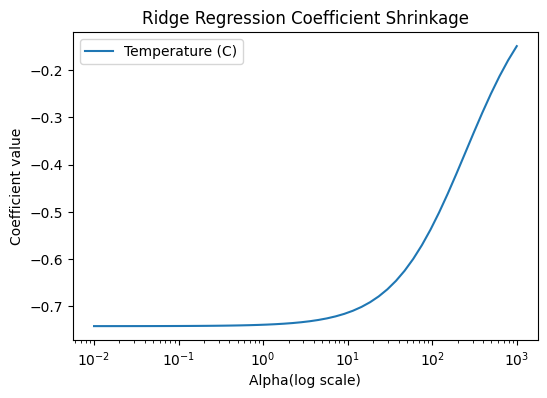

In [7]:
#Generate alpha values on log scale
alphas = np.logspace(-2, 3, 50)

#Store coefficients
coefficients_path = []

for alpha_value in alphas:
  ridge_model = Ridge(alpha=alpha_value)
  ridge_model.fit(x_train.values.reshape(-1, 1), y_train)
  coefficients_path.append(ridge_model.coef_)

  print(f"Alpha = {alpha_value:.4f} | Coefficients = {ridge_model.coef_}") #Printing coefficients

coefficients_path = np.array(coefficients_path) #Convert to numpy array

#plot
plt.figure(figsize=(6,4))
plt.plot(alphas, coefficients_path)
plt.xscale('log')
plt.xlabel('Alpha(log scale)')
plt.ylabel('Coefficient value')
plt.title('Ridge Regression Coefficient Shrinkage')
plt.legend([X.name])

In [8]:
# Linear Regression vs Ridge Regression R2 comparison
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Use same splits as notebook
X_train_lr = x_train.values.reshape(-1, 1)
X_val_lr = x_val.values.reshape(-1, 1)
X_test_lr = x_test.values.reshape(-1, 1)

linear_model = LinearRegression()
linear_model.fit(X_train_lr, y_train)

ridge_compare = Ridge(alpha=10)
ridge_compare.fit(X_train_lr, y_train)

# R2 scores
r2_train_linear = r2_score(y_train, linear_model.predict(X_train_lr))
r2_val_linear = r2_score(y_val, linear_model.predict(X_val_lr))
r2_test_linear = r2_score(y_test, linear_model.predict(X_test_lr))

r2_train_ridge = r2_score(y_train, ridge_compare.predict(X_train_lr))
r2_val_ridge = r2_score(y_val, ridge_compare.predict(X_val_lr))
r2_test_ridge = r2_score(y_test, ridge_compare.predict(X_test_lr))

print('--- Linear Regression R2 Scores ---')
print(f'Train R2: {r2_train_linear:.6f}')
print(f'Validation R2: {r2_val_linear:.6f}')
print(f'Test R2: {r2_test_linear:.6f}')

print('\n--- Ridge Regression R2 Scores (alpha=10) ---')
print(f'Train R2: {r2_train_ridge:.6f}')
print(f'Validation R2: {r2_val_ridge:.6f}')
print(f'Test R2: {r2_test_ridge:.6f}')

print('\n--- Difference (Ridge - Linear) ---')
print(f'Validation R2 diff: {r2_val_ridge - r2_val_linear:.6f}')
print(f'Test R2 diff: {r2_test_ridge - r2_test_linear:.6f}')


--- Linear Regression R2 Scores ---
Train R2: 0.026645
Validation R2: 0.029156
Test R2: -0.007649

--- Ridge Regression R2 Scores (alpha=10) ---
Train R2: 0.026606
Validation R2: 0.027594
Test R2: -0.006942

--- Difference (Ridge - Linear) ---
Validation R2 diff: -0.001563
Test R2 diff: 0.000708
